In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import netCDF4 as nc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert,load_swot_l2_unsmoothed  

In [12]:
# ── Files ──────────────────────────────────────────────────────────────────
DATA_DIR        = '/Volumes/PortableSSD/'
EXPERT_FILE     = 'SWOT_L2_LR_SSH_Expert_0524/SWOT_L2_LR_SSH_Expert_016_074_20240531T192537_20240531T201622_PGD0_01.nc'
UNSMOOTHED_FILE = 'SWOT_L2_LR_SSH_Unsmoothed_016_074_20240531T192538_20240531T201625_PGD0_01.nc'

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 250.0
OVERLAP           = 0.5
MAX_GAP_FRACTION  = 0.25
DETREND = 'constant'
# ── Box size ──────────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX, LON_MIN, LON_MAX = -60.0,60.0, 0.0, 360.0
BOX_DEG = 10.0

# ── Expert-product variable names ─────────────────────────────────────────────
SSH_VAR = 'ssha_karin_2'
HRET    = False   # add internal tide correction (height_cor_xover + internal_tide_hret)



In [13]:
data_expert = load_swot_l2_expert(DATA_DIR+EXPERT_FILE, ssh_var=SSH_VAR, HRET=HRET)
data_unsmoothed = load_swot_l2_unsmoothed(DATA_DIR+UNSMOOTHED_FILE, ssh_var=SSH_VAR, HRET=HRET)

In [14]:
def process_one_file(data, segment_length_km, overlap, max_gap_fraction, detrend,
                      lat_min, lat_max, lon_min, lon_max):
    import traceback as _tb

    try:
        result = compute_pass_spectra(
            ssha=data['ssha'],
            latitude=data['latitude'],
            longitude=data['longitude'],
            cross_track_distance=data['cross_track_distance'],
            segment_length_km=segment_length_km,
            overlap=overlap,
            max_gap_fraction=max_gap_fraction,
            detrend=detrend
        )
    except Exception:
        return ( f'spectra error:\n{_tb.format_exc()}', None)

    #granule_name = Path(filepath).stem
    kept, wavenumber = [], None
    for res in result.values():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        for seg in res.segments:
            if (lat_min <= seg.lat_mean <= lat_max and
                    lon_min <= seg.lon_mean <= lon_max):
                #seg._granule = granule_name
                kept.append(seg)

    return (kept, wavenumber)

In [15]:
all_segments_expert, wavenumber_exp   = process_one_file(data_expert,SEGMENT_LENGTH_KM, OVERLAP, MAX_GAP_FRACTION, DETREND,
                                       LAT_MIN, LAT_MAX, LON_MIN, LON_MAX
                                      )

In [16]:
all_segments_unsmooth, wavenumber_un = process_one_file(data_unsmoothed,SEGMENT_LENGTH_KM, OVERLAP, MAX_GAP_FRACTION, DETREND,
                                       LAT_MIN, LAT_MAX, LON_MIN, LON_MAX
                                      )

In [17]:
def segments_to_dataset(all_segments: list, wavenumber: np.ndarray) -> xr.Dataset:
    """Pack a flat list of SegmentSpectrum objects into an xarray.Dataset."""
    if not all_segments:
        raise ValueError('No segments to pack.')
    psd = np.stack([s.psd for s in all_segments], axis=0)
    return xr.Dataset(
        data_vars=dict(
            psd=(['segment', 'wavenumber'], psd,
                 {'long_name': 'Along-track SSH(A) PSD',
                  'units': 'm^2 / (cycles/km)'}),
            lat_mean=(['segment'], [s.lat_mean for s in all_segments],
                      {'units': 'degrees_north'}),
            lat_min=(['segment'],  [s.lat_min  for s in all_segments],
                     {'units': 'degrees_north'}),
            lat_max=(['segment'],  [s.lat_max  for s in all_segments],
                     {'units': 'degrees_north'}),
            lon_mean=(['segment'], [s.lon_mean for s in all_segments],
                      {'units': 'degrees_east'}),
            n_pixels_used=(['segment'], [s.n_pixels_used  for s in all_segments]),
            valid_fraction=(['segment'], [s.valid_fraction for s in all_segments]),
            swath=(['segment'],   [s.swath    for s in all_segments]),
            #granule=(['segment'], [s._granule for s in all_segments]),
            #year=(['segment'], [getattr(s, '_year', np.nan) for s in all_segments],
            #      {'long_name': 'Year of the source SWOT sub-directory'}),
            #month=(['segment'], [getattr(s, '_month', np.nan) for s in all_segments],
            #       {'long_name': 'Month of the source SWOT sub-directory'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            segment=('segment', np.arange(len(all_segments))),
        ),
    )

In [18]:
ds_segments_expert     = segments_to_dataset(all_segments_expert, wavenumber_exp)
ds_segments_unsmoothed = segments_to_dataset(all_segments_unsmooth, wavenumber_un)
print(f'Segment dataset (expert): {ds_segments_expert.sizes}')
print(f'Segment dataset (unsmoothed): {ds_segments_unsmoothed.sizes}')

Segment dataset (expert): Frozen({'segment': 158, 'wavenumber': 63})
Segment dataset (unsmoothed): Frozen({'segment': 161, 'wavenumber': 525})


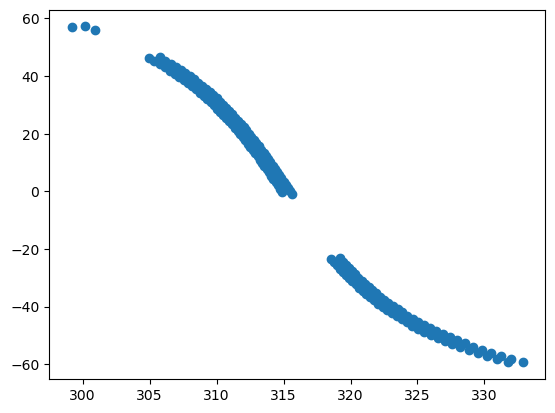

In [20]:
plt.scatter(ds_segments_expert.lon_mean,ds_segments_expert.lat_mean)

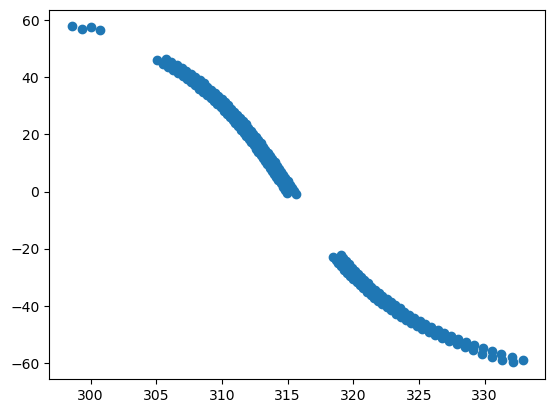

In [21]:
plt.scatter(ds_segments_unsmoothed.lon_mean,ds_segments_unsmoothed.lat_mean)

In [22]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all    = ds_segments['psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max

    psd_stack  = np.stack(rows_psd, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

In [25]:
boxes_expert     = build_box_dataset(ds_segments_expert)
boxes_unsmoothed = build_box_dataset(ds_segments_unsmoothed)

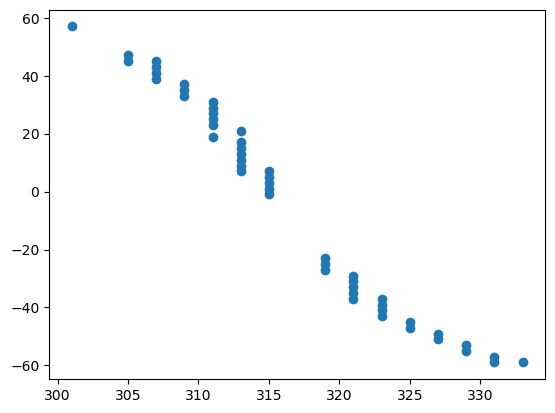

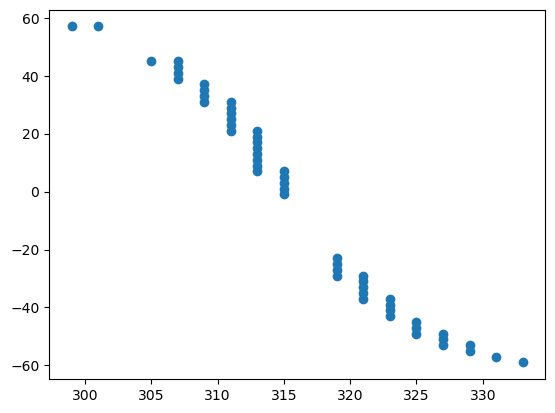

In [28]:
plt.scatter(boxes_expert.lon_center,boxes_expert.lat_center)
plt.figure()
plt.scatter(boxes_unsmoothed.lon_center,boxes_unsmoothed.lat_center)